#  NLP + CUSTOMER SENTIMENT ANALYSIS

In [3]:

# SMARTLOGIX AI
# NLP + CUSTOMER SENTIMENT ANALYSIS


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Load the actual dataset

In [4]:

# 1. LOAD CUSTOMER REVIEWS DATASET


file_path = "../cleaned_data/customer_reviews_cleaned.csv"

reviews = pd.read_csv(file_path)

print("Dataset loaded successfully.")

print("\nShape:")
print(reviews.shape)

print("\nColumns:")
print(reviews.columns.tolist())

print("\nFirst 5 rows:")
display(reviews.head())

Dataset loaded successfully.

Shape:
(12000, 12)

Columns:
['review_id', 'order_id', 'product_id', 'customer_id', 'rating', 'review_title', 'review_text', 'review_date', 'verified_purchase', 'helpful_votes', 'delivery_mode_experienced', 'sentiment_label']

First 5 rows:


,review_id,order_id,product_id,customer_id,rating,review_title,review_text,review_date,verified_purchase,helpful_votes,delivery_mode_experienced,sentiment_label
0,REV-000178,ORD-003669,PRD-00800,CUST-04230,5,NaN,"Packaging was excellent, product intact Tracki...",2024-12-24 21:44:00+00:00,False,NaN,Van,pos
1,REV-001266,ORD-009317,PRD-00595,CUST-04050,1,Delivery feedback,Package arrived damaged Item missing from the ...,2025-03-21 00:00:00+00:00,False,NaN,NaN,NaN
2,REV-008142,ORD-010864,PRD-00073,CUST-01504,3,Good,"Average experience Product fine, delivery slow...",2024-05-27 20:05:00+00:00,False,63.0,Drone,NaN
3,REV-008108,ORD-004311,PRD-00108,CUST-04970,3,Delivery feedback,"Average experience Product fine, delivery slow",2024-08-15 06:00:00+00:00,True,78.0,Drone,neu
4,REV-008239,ORD-009619,PRD-00789,CUST-04225,5,Bad experience,"Packaging was excellent, product intact Tracki...",2024-03-03 07:23:00+00:00,False,17.0,Van,pos


# Understand the sentiment labels

In [5]:

# 2. SENTIMENT LABEL ANALYSIS

print("Sentiment label distribution:")
print(reviews["sentiment_label"].value_counts(dropna=False))

print("\nMissing sentiment labels:")
print(reviews["sentiment_label"].isna().sum())

print("\nSentiment percentages:")
print(
    reviews["sentiment_label"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

Sentiment label distribution:
sentiment_label
pos    4240
NaN    4217
neg    1839
neu    1704
Name: count, dtype: int64

Missing sentiment labels:
4217

Sentiment percentages:
sentiment_label
pos    35.33
NaN    35.14
neg    15.32
neu    14.20
Name: proportion, dtype: float64


# Check the review text

In [6]:

# 3. REVIEW TEXT QUALITY CHECK

print("Missing review text:")
print(reviews["review_text"].isna().sum())

print("\nEmpty review text:")
print(
    reviews["review_text"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("\nReview examples:")
display(
    reviews[
        [
            "rating",
            "review_title",
            "review_text",
            "sentiment_label"
        ]
    ].head(10)
)

Missing review text:
464

Empty review text:
464

Review examples:


,rating,review_title,review_text,sentiment_label
0,5,NaN,"Packaging was excellent, product intact Tracki...",pos
1,1,Delivery feedback,Package arrived damaged Item missing from the ...,NaN
2,3,Good,"Average experience Product fine, delivery slow...",NaN
3,3,Delivery feedback,"Average experience Product fine, delivery slow",neu
4,5,Bad experience,"Packaging was excellent, product intact Tracki...",pos
5,1,NaN,Rider was rude on call Package arrived damaged,neg
6,3,Good,"Delivery was okay, nothing special Reached on ...",neu
7,5,NaN,Tracking updates were accurate Drone drop was ...,pos
8,1,NaN,Drone dropped parcel in wrong spot No tracking...,neg
9,5,Bad experience,Tracking updates were accurate Delivery was fa...,pos


# Create the NLP text

In [7]:

# 4. CREATE NLP TEXT


reviews["review_title"] = reviews["review_title"].fillna("")
reviews["review_text"] = reviews["review_text"].fillna("")

reviews["combined_text"] = (
    reviews["review_title"].astype(str)
    + " "
    + reviews["review_text"].astype(str)
)

reviews["combined_text"] = (
    reviews["combined_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print("Combined review text created.")

display(
    reviews[
        [
            "review_title",
            "review_text",
            "combined_text"
        ]
    ].head(10)
)

Combined review text created.


,review_title,review_text,combined_text
0,,"Packaging was excellent, product intact Tracki...","Packaging was excellent, product intact Tracki..."
1,Delivery feedback,Package arrived damaged Item missing from the ...,Delivery feedback Package arrived damaged Item...
2,Good,"Average experience Product fine, delivery slow...","Good Average experience Product fine, delivery..."
3,Delivery feedback,"Average experience Product fine, delivery slow",Delivery feedback Average experience Product f...
4,Bad experience,"Packaging was excellent, product intact Tracki...","Bad experience Packaging was excellent, produc..."
5,,Rider was rude on call Package arrived damaged,Rider was rude on call Package arrived damaged
6,Good,"Delivery was okay, nothing special Reached on ...","Good Delivery was okay, nothing special Reache..."
7,,Tracking updates were accurate Drone drop was ...,Tracking updates were accurate Drone drop was ...
8,,Drone dropped parcel in wrong spot No tracking...,Drone dropped parcel in wrong spot No tracking...
9,Bad experience,Tracking updates were accurate Delivery was fa...,Bad experience Tracking updates were accurate ...


# HANDLE MISSING VALUES FOR NLP

In [8]:

# 5. HANDLE MISSING VALUES FOR NLP


# Keep the original reviews dataframe unchanged

# Missing review titles → empty text
reviews["review_title"] = reviews["review_title"].fillna("")

# Missing review text → empty text
reviews["review_text"] = reviews["review_text"].fillna("")


# ------------------------------------------------------------
# Create combined text
# ------------------------------------------------------------

reviews["combined_text"] = (
    reviews["review_title"].astype(str)
    + " "
    + reviews["review_text"].astype(str)
)

reviews["combined_text"] = (
    reviews["combined_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)


# ------------------------------------------------------------
# Create training dataset
# ------------------------------------------------------------

sentiment_data = reviews[
    (reviews["combined_text"] != "") &
    (reviews["sentiment_label"].notna())
].copy()


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("Original dataset:", len(reviews))

print(
    "Reviews with usable text:",
    (reviews["combined_text"] != "").sum()
)

print(
    "Missing sentiment labels:",
    reviews["sentiment_label"].isna().sum()
)

print(
    "Final NLP training records:",
    len(sentiment_data)
)


# ------------------------------------------------------------
# Verify no missing values in training data
# ------------------------------------------------------------

print("\nMissing values in NLP training data:")

print(
    sentiment_data[
        ["combined_text", "sentiment_label"]
    ].isna().sum()
)


# ------------------------------------------------------------
# Sentiment distribution
# ------------------------------------------------------------

print("\nFinal sentiment distribution:")

print(
    sentiment_data["sentiment_label"].value_counts()
)

Original dataset: 12000
Reviews with usable text: 11829
Missing sentiment labels: 4217
Final NLP training records: 7674

Missing values in NLP training data:
combined_text      0
sentiment_label    0
dtype: int64

Final sentiment distribution:
sentiment_label
pos    4178
neg    1817
neu    1679
Name: count, dtype: int64


# Train/Test Split

In [9]:

# 6. TRAIN / TEST SPLIT


x= sentiment_data["combined_text"]

y = sentiment_data["sentiment_label"]




x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ------------------------------------------------------------
# Display dataset sizes
# ------------------------------------------------------------

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))


# ------------------------------------------------------------
# Training distribution
# ------------------------------------------------------------

print("\nTraining sentiment distribution:")

print(
    y_train.value_counts()
)


# ------------------------------------------------------------
# Testing distribution
# ------------------------------------------------------------

print("\nTesting sentiment distribution:")

print(
    y_test.value_counts()
)

Training samples: 6139
Testing samples: 1535

Training sentiment distribution:
sentiment_label
pos    3342
neg    1454
neu    1343
Name: count, dtype: int64

Testing sentiment distribution:
sentiment_label
pos    836
neg    363
neu    336
Name: count, dtype: int64


# TF-IDF Vectorization

In [10]:
# ============================================================
# 7. TF-IDF TEXT VECTORIZATION
# ============================================================

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    max_features=10000,
    min_df=2
)


# ------------------------------------------------------------
# Fit and transform training data
# ------------------------------------------------------------

x_train_tfidf = tfidf.fit_transform(x_train)


# ------------------------------------------------------------
# Transform test data
# ------------------------------------------------------------

x_test_tfidf = tfidf.transform(x_test)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("TF-IDF vectorization completed.")

print("\nTraining matrix shape:")
print(x_train_tfidf.shape)

print("\nTesting matrix shape:")
print(x_test_tfidf.shape)

print("\nVocabulary size:")
print(len(tfidf.vocabulary_))

TF-IDF vectorization completed.

Training matrix shape:
(6139, 224)

Testing matrix shape:
(1535, 224)

Vocabulary size:
224


# Train the Sentiment Classifier

Create Logistic Regression model

In [11]:

# 8. SENTIMENT CLASSIFICATION MODEL

# Create Logistic Regression model
sentiment_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


# Train the model

sentiment_model.fit(
    x_train_tfidf,
    y_train
)


print("Sentiment model training completed.")


# ------------------------------------------------------------
# Display learned classes
# ------------------------------------------------------------

print("\nSentiment classes:")
print(sentiment_model.classes_)

Sentiment model training completed.

Sentiment classes:
['neg' 'neu' 'pos']


# Evaluate the NLP model

In [12]:

# 9. SENTIMENT MODEL EVALUATION

# ------------------------------------------------------------
# Make predictions on test data
# ------------------------------------------------------------

y_pred = sentiment_model.predict(x_test_tfidf)


# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Sentiment Model Accuracy:")
print(f"{accuracy:.4f}")


# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        labels=["neg", "neu", "pos"],
        target_names=[
            "Negative",
            "Neutral",
            "Positive"
        ],
        digits=4
    )
)


# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["neg", "neu", "pos"]
)


print("\nConfusion Matrix:")
print(cm)

Sentiment Model Accuracy:
0.9883

Classification Report:
              precision    recall  f1-score   support

    Negative     1.0000    0.9780    0.9889       363
     Neutral     1.0000    0.9702    0.9849       336
    Positive     0.9789    1.0000    0.9893       836

    accuracy                         0.9883      1535
   macro avg     0.9930    0.9827    0.9877      1535
weighted avg     0.9885    0.9883    0.9883      1535


Confusion Matrix:
[[355   0   8]
 [  0 326  10]
 [  0   0 836]]


In [13]:

# 10. SENTIMENT ANALYSIS BY RATING


# Create a clean dataset using the original reviews dataframe
rating_data = reviews[
    reviews["sentiment_label"].notna()
    & reviews["combined_text"].notna()
    & (reviews["combined_text"].str.strip() != "")
].copy()


# ------------------------------------------------------------
# Sentiment distribution by rating
# ------------------------------------------------------------

rating_sentiment = (
    rating_data
    .groupby(["rating", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
)


# Keep sentiment columns in consistent order
rating_sentiment = rating_sentiment.reindex(
    columns=["neg", "neu", "pos"],
    fill_value=0
)


print("Sentiment distribution by rating:")

display(rating_sentiment)


# ------------------------------------------------------------
# Convert counts to percentages
# ------------------------------------------------------------

rating_sentiment_pct = (
    rating_sentiment
    .div(rating_sentiment.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)


print("\nSentiment percentage by rating:")

display(rating_sentiment_pct)

Sentiment distribution by rating:


sentiment_label,neg,neu,pos
rating,,,
1,932,0,0
2,885,0,0
3,0,1679,0
4,0,0,1384
5,0,0,2794



Sentiment percentage by rating:


sentiment_label,neg,neu,pos
rating,,,
1,100.0,0.0,0.0
2,100.0,0.0,0.0
3,0.0,100.0,0.0
4,0.0,0.0,100.0
5,0.0,0.0,100.0


# Sentiment by Delivery Mode

In [14]:

# 11. SENTIMENT ANALYSIS BY DELIVERY MODE


# Use reviews with known sentiment and delivery mode
delivery_sentiment = reviews[
    reviews["sentiment_label"].notna()
    & reviews["delivery_mode_experienced"].notna()
].copy()


# Count sentiment by delivery mode


delivery_sentiment_counts = (
    delivery_sentiment
    .groupby([
        "delivery_mode_experienced",
        "sentiment_label"
    ])
    .size()
    .unstack(fill_value=0)
)


# Keep consistent sentiment order
delivery_sentiment_counts = delivery_sentiment_counts.reindex(
    columns=["neg", "neu", "pos"],
    fill_value=0
)


print("Sentiment distribution by delivery mode:")

display(delivery_sentiment_counts)


# Convert to percentages


delivery_sentiment_pct = (
    delivery_sentiment_counts
    .div(
        delivery_sentiment_counts.sum(axis=1),
        axis=0
    )
    .mul(100)
    .round(2)
)


print("\nSentiment percentage by delivery mode:")

display(delivery_sentiment_pct)

Sentiment distribution by delivery mode:


sentiment_label,neg,neu,pos
delivery_mode_experienced,,,
Bike,291,287,707
Drone,589,560,1408
Truck,318,263,711
Van,327,296,723



Sentiment percentage by delivery mode:


sentiment_label,neg,neu,pos
delivery_mode_experienced,,,
Bike,22.65,22.33,55.02
Drone,23.03,21.90,55.06
Truck,24.61,20.36,55.03
Van,24.29,21.99,53.71


# Product-level sentiment analysis

In [15]:
# Product-level sentiment analysis

product_sentiment = reviews[
    reviews["product_id"].notna()
    & reviews["sentiment_label"].notna()
    & reviews["combined_text"].notna()
    & (reviews["combined_text"].str.strip() != "")
].copy()


# Sentiment counts by product

product_sentiment_counts = (
    product_sentiment
    .groupby(["product_id", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
)


# Keep sentiment columns in consistent order

product_sentiment_counts = product_sentiment_counts.reindex(
    columns=["neg", "neu", "pos"],
    fill_value=0
)


# Total reviews per product

product_sentiment_counts["total_reviews"] = (
    product_sentiment_counts[["neg", "neu", "pos"]].sum(axis=1)
)


# Positive sentiment percentage

product_sentiment_counts["positive_pct"] = (
    product_sentiment_counts["pos"]
    / product_sentiment_counts["total_reviews"]
    * 100
).round(2)


# Negative sentiment percentage

product_sentiment_counts["negative_pct"] = (
    product_sentiment_counts["neg"]
    / product_sentiment_counts["total_reviews"]
    * 100
).round(2)


# Sort products by number of reviews

product_sentiment_counts = product_sentiment_counts.sort_values(
    "total_reviews",
    ascending=False
)


# Display results

display(product_sentiment_counts.head(20))

sentiment_label,neg,neu,pos,total_reviews,positive_pct,negative_pct
product_id,,,,,,
PRD-00707,4,4,9,17,52.94,23.53
PRD-00724,5,2,10,17,58.82,29.41
PRD-00698,7,4,6,17,35.29,41.18
PRD-00078,5,5,6,16,37.50,31.25
PRD-00004,5,3,8,16,50.00,31.25
PRD-00647,1,3,12,16,75.00,6.25
PRD-00264,2,5,9,16,56.25,12.50
PRD-00477,2,6,8,16,50.00,12.50
PRD-00701,2,3,11,16,68.75,12.50


# Reliable product sentiment

In [16]:
# Filter products with at least 10 reviews

reliable_products = product_sentiment_counts[
    product_sentiment_counts["total_reviews"] >= 10
].copy()


# Top products by positive sentiment

top_positive_products = reliable_products.sort_values(
    "positive_pct",
    ascending=False
).head(10)


# Top products by negative sentiment

top_negative_products = reliable_products.sort_values(
    "negative_pct",
    ascending=False
).head(10)


print("Top 10 products by positive sentiment:")

display(
    top_positive_products[
        [
            "neg",
            "neu",
            "pos",
            "total_reviews",
            "positive_pct",
            "negative_pct"
        ]
    ]
)


print("\nTop 10 products by negative sentiment:")

display(
    top_negative_products[
        [
            "neg",
            "neu",
            "pos",
            "total_reviews",
            "positive_pct",
            "negative_pct"
        ]
    ]
)

Top 10 products by positive sentiment:


sentiment_label,neg,neu,pos,total_reviews,positive_pct,negative_pct
product_id,,,,,,
PRD-00814,0,1,12,13,92.31,0.00
PRD-00206,1,0,10,11,90.91,9.09
PRD-00168,0,1,10,11,90.91,0.00
PRD-00124,0,1,9,10,90.00,0.00
PRD-00414,0,1,9,10,90.00,0.00
PRD-00778,1,1,13,15,86.67,6.67
PRD-00672,1,1,12,14,85.71,7.14
PRD-00063,1,1,11,13,84.62,7.69
PRD-00426,1,1,10,12,83.33,8.33



Top 10 products by negative sentiment:


sentiment_label,neg,neu,pos,total_reviews,positive_pct,negative_pct
product_id,,,,,,
PRD-00526,7,1,2,10,20.00,70.00
PRD-00527,6,2,2,10,20.00,60.00
PRD-00356,7,0,5,12,41.67,58.33
PRD-00596,7,0,5,12,41.67,58.33
PRD-00537,6,1,4,11,36.36,54.55
PRD-00434,5,3,2,10,20.00,50.00
PRD-00543,6,2,4,12,33.33,50.00
PRD-00444,5,2,3,10,30.00,50.00
PRD-00715,7,3,4,14,28.57,50.00


# visualize the findings

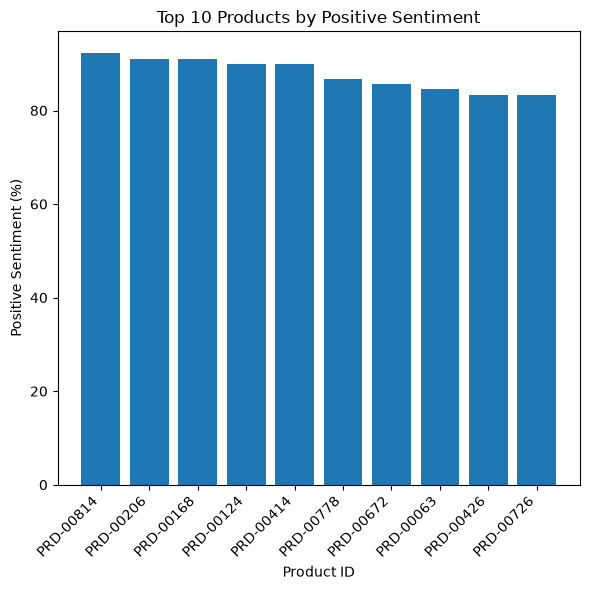

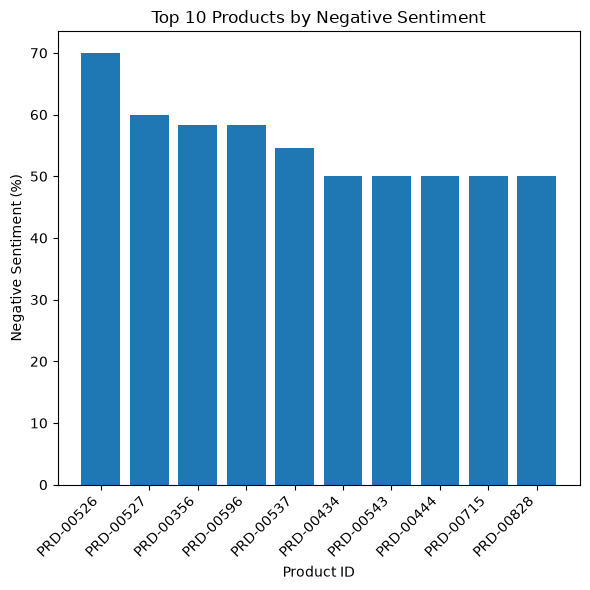

In [20]:
# Top 10 products by positive sentiment

plt.figure(figsize=(6, 6))

plt.bar(
    top_positive_products.index,
    top_positive_products["positive_pct"]
)

plt.xlabel("Product ID")
plt.ylabel("Positive Sentiment (%)")
plt.title("Top 10 Products by Positive Sentiment")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


# Top 10 products by negative sentiment

plt.figure(figsize=(6, 6))

plt.bar(
    top_negative_products.index,
    top_negative_products["negative_pct"]
)

plt.xlabel("Product ID")
plt.ylabel("Negative Sentiment (%)")
plt.title("Top 10 Products by Negative Sentiment")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()